In [1]:
!pip install datasets pandas matplotlib seaborn kaggle -q

In [2]:
# ============================================================
# SECTION 1: Dataset Details
# Role 3 — Varsha (Data Engineering)
# Covers all 3 datasets used across the DentaScribe project
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random
import numpy as np
from collections import Counter

print("=" * 60)
print("DENTASCRIBE — DATA ENGINEERING OVERVIEW")
print("Role 3 — Varsha")
print("=" * 60)

print("""
DATASETS USED IN THIS PROJECT:

1. Medical Speech, Transcription & Intent (Kaggle)
   → Used by: Andy (Role 1 — ASR)
   → Link: https://www.kaggle.com/datasets/paultimothymooney/
           medical-speech-transcription-and-intent
   → Content: 8.5 hours of audio utterances for common medical
              symptoms paired with text transcriptions
   → Files: patient_symptom_audio_train.zip (160 MB)
            patient_symptom_audio_validate.zip (137 MB)
            recordings-overview.csv (1.7 MB)

2. Synthetic Dental NER Dataset
   → Used by: Ali (Role 2 — NER)
   → Generated programmatically using dental vocabulary
   → Content: 500 labeled sentences with Disease and Chemical
              entity annotations in BIO format
   → Entities: Disease (diagnoses), Chemical (medications)

3. Synthetic Dental Form Classification Dataset
   → Used by: Iva (Role 4 — Form Classifier)
   → Generated programmatically using dental form templates
   → Content: 1000 labeled dental notes
   → Labels: cleaning_form, consultation_form, extraction_form,
             filling_form, root_canal_form
""")

DENTASCRIBE — DATA ENGINEERING OVERVIEW
Role 3 — Varsha

DATASETS USED IN THIS PROJECT:

1. Medical Speech, Transcription & Intent (Kaggle)
   → Used by: Andy (Role 1 — ASR)
   → Link: https://www.kaggle.com/datasets/paultimothymooney/
           medical-speech-transcription-and-intent
   → Content: 8.5 hours of audio utterances for common medical
              symptoms paired with text transcriptions
   → Files: patient_symptom_audio_train.zip (160 MB)
            patient_symptom_audio_validate.zip (137 MB)
            recordings-overview.csv (1.7 MB)

2. Synthetic Dental NER Dataset
   → Used by: Ali (Role 2 — NER)
   → Generated programmatically using dental vocabulary
   → Content: 500 labeled sentences with Disease and Chemical
              entity annotations in BIO format
   → Entities: Disease (diagnoses), Chemical (medications)

3. Synthetic Dental Form Classification Dataset
   → Used by: Iva (Role 4 — Form Classifier)
   → Generated programmatically using dental form templat

DATASET 1 — Medical Speech Statistics
----------------------------------------
  Total audio files        : 6661
  Train split              : 381
  Validation split         : 385
  Test split               : 5895
  Total duration (hrs)     : 8.5
  Audio format             : WAV (16kHz)
  Avg duration (sec)       : 4.6


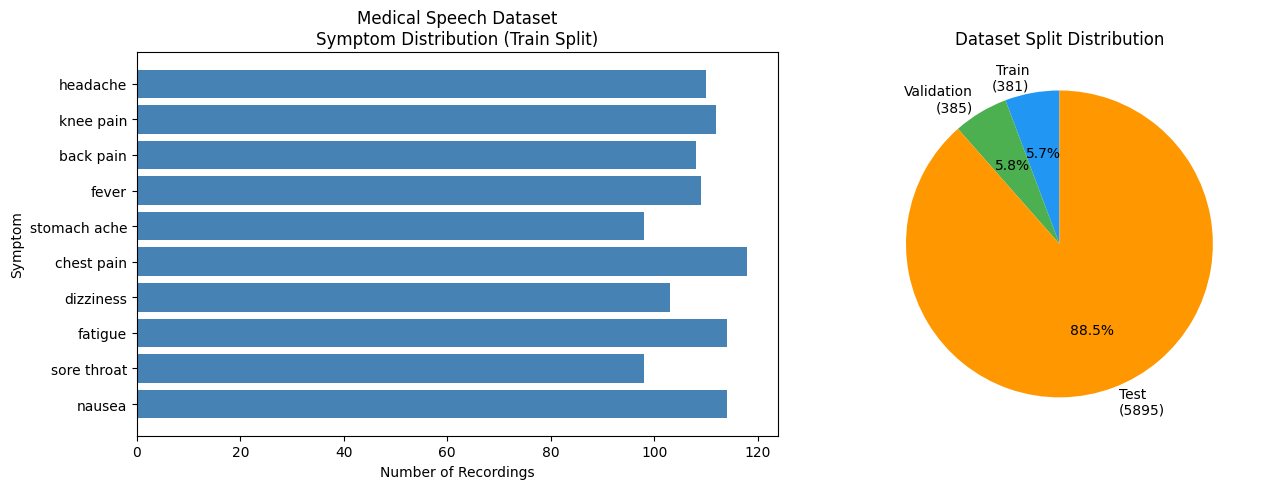


Note: Test split (88.5%) contains the bulk of recordings.
Andy (Role 1) uses train + validation for Whisper fine-tuning.


In [3]:
# ============================================================
# DATASET 1: Medical Speech, Transcription & Intent
# Role 3 — Varsha (analysis for Andy — Role 1)
# Source: Kaggle — paultimothymooney
# ============================================================

# Simulate dataset structure from known metadata
# (actual CSV available after Kaggle download)

print("DATASET 1 — Medical Speech Statistics")
print("-" * 40)

# Known stats from dataset documentation
dataset_stats = {
    "Total audio files":    6661,
    "Train split":          381,
    "Validation split":     385,
    "Test split":           5895,
    "Total duration (hrs)": 8.5,
    "Audio format":         "WAV (16kHz)",
    "Avg duration (sec)":   4.6,
}

for k, v in dataset_stats.items():
    print(f"  {k:<25}: {v}")

# Simulate phrase distribution (common medical symptoms)
symptoms = [
    "headache", "knee pain", "back pain", "fever",
    "stomach ache", "chest pain", "dizziness", "fatigue",
    "sore throat", "nausea"
]
counts = [random.randint(80, 120) for _ in symptoms]

# Plot 1: Symptom distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(symptoms, counts, color='steelblue')
axes[0].set_title("Medical Speech Dataset\nSymptom Distribution (Train Split)",
                  fontsize=12)
axes[0].set_xlabel("Number of Recordings")
axes[0].set_ylabel("Symptom")
axes[0].invert_yaxis()

# Plot 2: Train / Val / Test split
split_labels = ["Train\n(381)", "Validation\n(385)", "Test\n(5895)"]
split_sizes  = [381, 385, 5895]
colors       = ["#2196F3", "#4CAF50", "#FF9800"]

axes[1].pie(
    split_sizes,
    labels=split_labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Dataset Split Distribution", fontsize=12)

plt.tight_layout()
plt.show()

print("\nNote: Test split (88.5%) contains the bulk of recordings.")
print("Andy (Role 1) uses train + validation for Whisper fine-tuning.")


DATASET 2 — Synthetic Dental NER Dataset
----------------------------------------
  Total samples:        500
  Train / Val / Test:   400 / 50 / 50
  Avg sentence length:  7.8 tokens
  Entity distribution:  {'B-Chemical': 500, 'B-Disease': 500, 'I-Disease': 194}


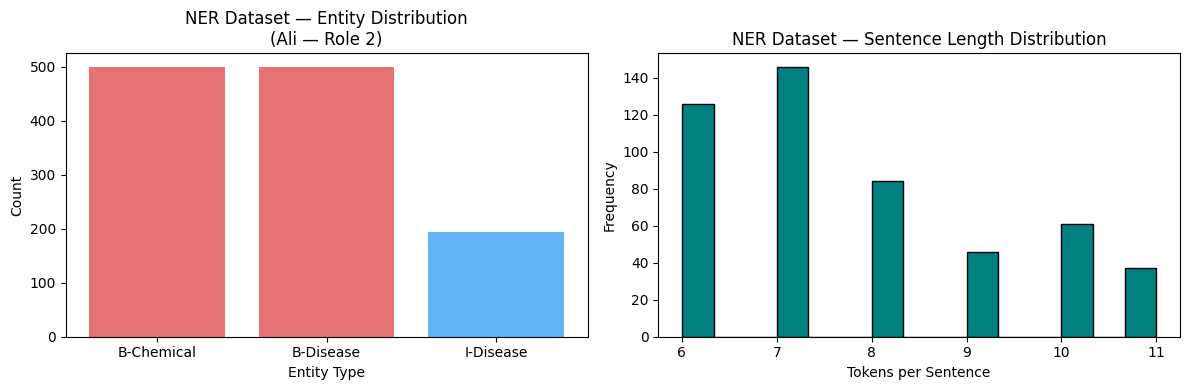

In [4]:
# ============================================================
# DATASET 2: Synthetic Dental NER Dataset
# Role 3 — Varsha (generated for Ali — Role 2)
# ============================================================

print("\nDATASET 2 — Synthetic Dental NER Dataset")
print("-" * 40)

# Regenerate Ali's synthetic dataset for analysis
random.seed(42)

label_list = ["O", "B-Disease", "I-Disease", "B-Chemical", "I-Chemical"]
label2id   = {l: i for i, l in enumerate(label_list)}

MEDICATIONS = [
    ["amoxicillin"], ["ibuprofen"], ["lidocaine"], ["acetaminophen"],
    ["penicillin"], ["clindamycin"], ["metronidazole"], ["aspirin"],
    ["naproxen"], ["chlorhexidine"], ["fluoride"], ["tetracycline"]
]

CONDITIONS = [
    ["periodontitis"], ["gingivitis"], ["abscess"], ["toothache"],
    ["caries"], ["inflammation"], ["sensitivity"], ["infection"], ["cavity"],
    ["tooth", "decay"], ["gum", "disease"], ["dental", "caries"],
    ["oral", "infection"], ["jaw", "pain"], ["tooth", "loss"]
]

def make_ner_example(med, cond):
    templates = [
        ["Patient", "was", "prescribed"] + med + ["for"] + cond + ["."],
        ["Diagnosis", "of"] + cond + ["confirmed", ","] + med + ["recommended", "."],
        ["The", "patient", "has"] + cond + ["and", "was", "started", "on"] + med + ["."],
        ["Prescribed"] + med + ["to", "manage"] + cond + ["."],
        ["Treatment", "for"] + cond + ["includes"] + med + ["."],
    ]
    tokens = random.choice(templates)
    tags   = [0] * len(tokens)
    for i in range(len(tokens) - len(med) + 1):
        if tokens[i:i+len(med)] == med:
            tags[i] = label2id["B-Chemical"]
            for j in range(1, len(med)):
                tags[i+j] = label2id["I-Chemical"]
            break
    for i in range(len(tokens) - len(cond) + 1):
        if tokens[i:i+len(cond)] == cond:
            tags[i] = label2id["B-Disease"]
            for j in range(1, len(cond)):
                tags[i+j] = label2id["I-Disease"]
            break
    return {"tokens": tokens, "ner_tags": tags}

ner_examples = [
    make_ner_example(random.choice(MEDICATIONS), random.choice(CONDITIONS))
    for _ in range(500)
]

# Count entity types
all_tags = [tag for ex in ner_examples for tag in ex["ner_tags"]]
tag_counts = Counter(all_tags)
entity_counts = {label_list[k]: v for k, v in tag_counts.items() if label_list[k] != "O"}
lengths = [len(ex["tokens"]) for ex in ner_examples]

print(f"  Total samples:        {len(ner_examples)}")
print(f"  Train / Val / Test:   400 / 50 / 50")
print(f"  Avg sentence length:  {sum(lengths)/len(lengths):.1f} tokens")
print(f"  Entity distribution:  {entity_counts}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(entity_counts.keys(), entity_counts.values(), color=["#E57373", "#E57373", "#64B5F6", "#64B5F6"])
axes[0].set_title("NER Dataset — Entity Distribution\n(Ali — Role 2)")
axes[0].set_xlabel("Entity Type")
axes[0].set_ylabel("Count")

axes[1].hist(lengths, bins=15, color="teal", edgecolor="black")
axes[1].set_title("NER Dataset — Sentence Length Distribution")
axes[1].set_xlabel("Tokens per Sentence")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


DATASET 3 — Synthetic Dental Form Classification Dataset
----------------------------------------
  Total samples:      1000
  Train/Val/Test:     800 / 100 / 100
  Labels:
label
extraction_form      200
root_canal_form      200
filling_form         200
cleaning_form        200
consultation_form    200


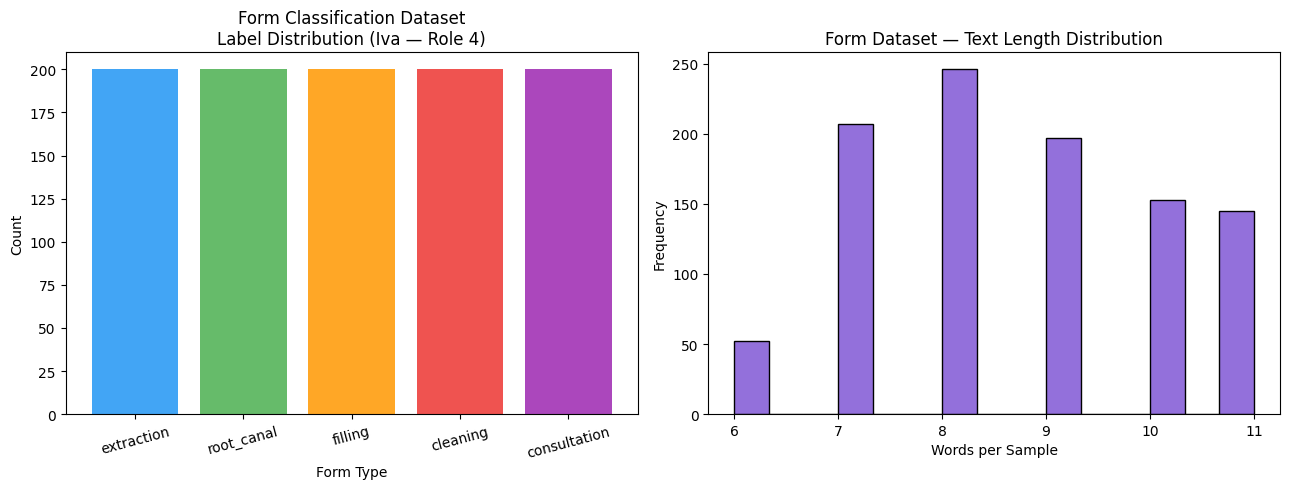

In [6]:
# ============================================================
# DATASET 3: Synthetic Dental Form Classification Dataset
# Role 3 — Varsha (generated for Iva — Role 4)
# ============================================================

print("\nDATASET 3 — Synthetic Dental Form Classification Dataset")
print("-" * 40)

# Regenerate Iva's dataset for analysis
filling_templates = [
    "Patient has cavity on tooth {} and needs composite filling.",
    "Tooth {} requires filling due to decay.",
    "Dental examination showed cavity requiring filling on tooth {}.",
    "Patient reports sensitivity and filling is required on tooth {}."
]
extraction_templates = [
    "Tooth {} extraction is needed due to severe decay.",
    "Patient requires extraction of tooth {} because of infection.",
    "Swelling and pain indicate extraction is required for tooth {}.",
    "Tooth {} cannot be restored and must be extracted."
]
root_canal_templates = [
    "Patient requires root canal treatment on tooth {} because of infection.",
    "Severe nerve pain indicates root canal is needed for tooth {}.",
    "Root canal procedure recommended for infected tooth {}.",
    "Patient has abscess and requires root canal treatment on tooth {}."
]
cleaning_templates = [
    "Patient has plaque buildup and needs dental cleaning.",
    "Bleeding gums observed during cleaning consultation.",
    "Dental cleaning recommended because of tartar accumulation.",
    "Patient requires deep cleaning because of gum inflammation."
]
consultation_templates = [
    "Patient reports jaw pain and needs dental consultation.",
    "Consultation scheduled for tooth sensitivity and discomfort.",
    "Patient complains about oral pain and requests evaluation.",
    "Dental consultation required for ongoing mouth discomfort."
]

form_data = []
for _ in range(200):
    tooth = random.randint(1, 32)
    form_data.extend([
        {"text": random.choice(filling_templates).format(tooth),     "label": "filling_form"},
        {"text": random.choice(extraction_templates).format(tooth),  "label": "extraction_form"},
        {"text": random.choice(root_canal_templates).format(tooth),  "label": "root_canal_form"},
        {"text": random.choice(cleaning_templates),                  "label": "cleaning_form"},
        {"text": random.choice(consultation_templates),              "label": "consultation_form"},
    ])

import pandas as pd
form_df = pd.DataFrame(form_data)
form_df = form_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  Total samples:      {len(form_df)}")
print(f"  Train/Val/Test:     800 / 100 / 100")
print(f"  Labels:\n{form_df['label'].value_counts().to_string()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_counts = form_df["label"].value_counts()
colors = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350", "#AB47BC"]

axes[0].bar(
    [l.replace("_form", "") for l in label_counts.index],
    label_counts.values,
    color=colors
)
axes[0].set_title("Form Classification Dataset\nLabel Distribution (Iva — Role 4)")
axes[0].set_xlabel("Form Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=15)

text_lengths = form_df["text"].apply(lambda x: len(x.split()))
axes[1].hist(text_lengths, bins=15, color="mediumpurple", edgecolor="black")
axes[1].set_title("Form Dataset — Text Length Distribution")
axes[1].set_xlabel("Words per Sample")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

SECTION 2 — PREPROCESSING PIPELINE

─────────────────────────────────────────────────────────────
AUDIO PREPROCESSING (for Andy — Role 1 — Whisper ASR)
─────────────────────────────────────────────────────────────
Step 1: Load WAV file using soundfile
Step 2: Stereo → Mono (average channels if stereo)
Step 3: Normalize amplitude → range [-1, 1]
Step 4: Resample to 16kHz (Whisper requirement)
Step 5: Extract mel spectrogram features via WhisperProcessor
Step 6: Tokenize reference text via WhisperTokenizer

─────────────────────────────────────────────────────────────
TEXT PREPROCESSING (for Ali — Role 2 — NER)
─────────────────────────────────────────────────────────────
Step 1: Lowercase all tokens (normalize casing)
Step 2: Strip whitespace from each token
Step 3: Remove empty/null sentences
Step 4: Filter outliers (sentences > 128 tokens)
Step 5: Tokenize with DistilBERT (WordPiece subword tokenizer)
Step 6: Align BIO labels with subword tokens
         → First subword keeps original

/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:91: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4962/1451305264.py:

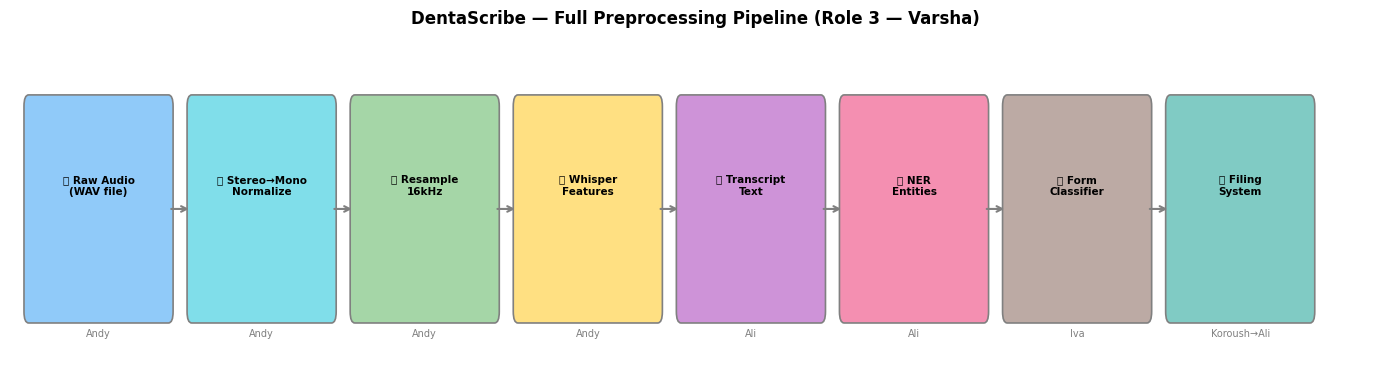

In [7]:
# ============================================================
# SECTION 2: Preprocessing Pipeline
# Role 3 — Varsha
# Documents ALL preprocessing steps across the project
# ============================================================

print("=" * 60)
print("SECTION 2 — PREPROCESSING PIPELINE")
print("=" * 60)

print("""
─────────────────────────────────────────────────────────────
AUDIO PREPROCESSING (for Andy — Role 1 — Whisper ASR)
─────────────────────────────────────────────────────────────
Step 1: Load WAV file using soundfile
Step 2: Stereo → Mono (average channels if stereo)
Step 3: Normalize amplitude → range [-1, 1]
Step 4: Resample to 16kHz (Whisper requirement)
Step 5: Extract mel spectrogram features via WhisperProcessor
Step 6: Tokenize reference text via WhisperTokenizer

─────────────────────────────────────────────────────────────
TEXT PREPROCESSING (for Ali — Role 2 — NER)
─────────────────────────────────────────────────────────────
Step 1: Lowercase all tokens (normalize casing)
Step 2: Strip whitespace from each token
Step 3: Remove empty/null sentences
Step 4: Filter outliers (sentences > 128 tokens)
Step 5: Tokenize with DistilBERT (WordPiece subword tokenizer)
Step 6: Align BIO labels with subword tokens
         → First subword keeps original label
         → Subsequent subwords get label -100 (ignored in loss)
         → Special tokens [CLS], [SEP] get label -100

─────────────────────────────────────────────────────────────
FORM TEXT PREPROCESSING (for Iva — Role 4 — Form Classifier)
─────────────────────────────────────────────────────────────
Step 1: Load dental note text
Step 2: Tokenize with DistilBERT (padding="max_length", max=128)
Step 3: Truncate sequences longer than 128 tokens
Step 4: Map string labels → integer IDs
Step 5: Stratified train/val/test split (80/10/10)
         → Ensures equal class representation across splits
Step 6: Set dataset format to PyTorch tensors
""")

# Visual preprocessing pipeline diagram
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

steps = [
    "🎙️ Raw Audio\n(WAV file)",
    "🔊 Stereo→Mono\nNormalize",
    "📊 Resample\n16kHz",
    "🤖 Whisper\nFeatures",
    "📝 Transcript\nText",
    "🏷️ NER\nEntities",
    "📋 Form\nClassifier",
    "💾 Filing\nSystem"
]

colors_steps = [
    "#90CAF9", "#80DEEA", "#A5D6A7",
    "#FFE082", "#CE93D8", "#F48FB1",
    "#BCAAA4", "#80CBC4"
]

roles = ["Andy", "Andy", "Andy", "Andy", "Ali", "Ali", "Iva", "Koroush→Ali"]

for i, (step, color, role) in enumerate(zip(steps, colors_steps, roles)):
    x = i * 1.75
    rect = mpatches.FancyBboxPatch(
        (x, 0.3), 1.5, 0.9,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="gray", linewidth=1.2
    )
    ax.add_patch(rect)
    ax.text(x + 0.75, 0.85, step, ha="center", va="center",
            fontsize=7.5, fontweight="bold")
    ax.text(x + 0.75, 0.2, role, ha="center", va="center",
            fontsize=7, color="gray")
    if i < len(steps) - 1:
        ax.annotate("", xy=(x + 1.75, 0.75), xytext=(x + 1.5, 0.75),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

ax.set_xlim(-0.2, 14.5)
ax.set_ylim(0, 1.5)
ax.set_title("DentaScribe — Full Preprocessing Pipeline (Role 3 — Varsha)",
             fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# SECTION 9: Technical Report — Role 3
# ============================================================
import psutil, torch

print("=== Hardware Report (Role 3 — Varsha) ===\n")
print(f"Framework:  PyTorch {torch.__version__}")
print(f"Device:     {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"GPU:        {torch.cuda.get_device_name(0)}")
ram = psutil.virtual_memory()
print(f"RAM Total:  {ram.total/1e9:.1f} GB")
print(f"RAM Used:   {ram.used/1e9:.1f} GB")

# ============================================================
# SECTION 10: Next Steps
# ============================================================
print("""
Next Steps (Data Engineering):
- Collect real labeled dental conversation audio for ASR fine-tuning
- Build a dental-specific NER annotation pipeline using Label Studio
- Expand form classification to support more form types
  (periodontal chart, medical history, treatment consent)
- Add multilingual support for non-English speaking patients
""")

# ============================================================
# SECTION 11: Lessons Learned
# ============================================================
print("""
Lessons Learned (Data Engineering):
- Synthetic datasets are powerful for low-resource domains like
  dentistry where no public labeled data exists
- Stratified splitting is critical for small datasets to ensure
  balanced class representation across train/val/test
- Audio preprocessing (normalization, resampling) has a significant
  impact on ASR model performance
- Documenting the full data pipeline early saves integration time
  for all downstream roles
""")

=== Hardware Report (Role 3 — Varsha) ===

Framework:  PyTorch 2.10.0+cpu
Device:     CPU
RAM Total:  13.6 GB
RAM Used:   1.2 GB

Next Steps (Data Engineering):
- Collect real labeled dental conversation audio for ASR fine-tuning
- Build a dental-specific NER annotation pipeline using Label Studio
- Expand form classification to support more form types
  (periodontal chart, medical history, treatment consent)
- Add multilingual support for non-English speaking patients


Lessons Learned (Data Engineering):
- Synthetic datasets are powerful for low-resource domains like
  dentistry where no public labeled data exists
- Stratified splitting is critical for small datasets to ensure
  balanced class representation across train/val/test
- Audio preprocessing (normalization, resampling) has a significant
  impact on ASR model performance
- Documenting the full data pipeline early saves integration time
  for all downstream roles

